# 02 - Treinamento da LSTM para previsão de taxas de gas

Este notebook ilustra o pipeline completo:

1. **Geração do dataset** — 5 dias de dados via GoldRush (block_v2).
2. **Preparação** — Carregamento, limpeza, normalização e sequências temporais.
3. **Treino** — Modelo LSTM e avaliação em validação/teste.
4. **Comparação** — Gráficos de valor real vs predito e curva de loss no treino.


In [3]:
# Configuração e imports
# Use o kernel do .venv do projeto (Select Kernel -> Python Environments -> .venv).
# Se der ModuleNotFoundError, ative o venv, rode: pip install -r requirements.txt
# e selecione esse interpretador como kernel.
import sys
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib  # deve estar instalado no kernel (ex.: pip install -r requirements.txt no .venv)
import matplotlib.pyplot as plt
%matplotlib inline

# Raiz do projeto (assumindo que o notebook está em notebooks/)
ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from datetime import datetime, timedelta

from src.data.fetch_blocks_goldrush import (
    _date_to_block_range,
    date_to_block_range_hours,
    fetch_blockchain_data,
)
from src.features.build_features import (
    SequenceConfig,
    clean_data,
    create_sequences,
    load_raw_data,
    scale_features,
    train_val_test_split,
)
from src.models.lstm_model import build_lstm_model, save_model, train_lstm

DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
MODEL_PATH = MODEL_DIR / "lstm_gas_price.h5"
SCALER_PATH = MODEL_DIR / "scaler.pkl"

INPUT_CSV = "EthereumGasFee.csv"  # arquivo em data/ (Date, Mean, Median, Percentile_75, Percentile_25). None = gerar via API.

if INPUT_CSV:
    p = Path(INPUT_CSV)
    CSV_OUT = p.resolve() if p.is_absolute() else DATA_DIR / p.name
    print(f"Processando dataset existente: {CSV_OUT}")
else:
    CHAIN = "eth-mainnet"
    BLOCKS_PER_HOUR = {"eth-mainnet": 300, "matic-mainnet": 1800}
    N_BLOCOS_1H = int(BLOCKS_PER_HOUR.get(CHAIN, 300))
    MODO_ULTIMA_HORA = True
    if MODO_ULTIMA_HORA:
        ONTEM = (datetime.utcnow() - timedelta(days=1)).strftime("%Y-%m-%d")
        START_BLOCK, END_BLOCK = date_to_block_range_hours(ONTEM, 1.0, CHAIN)
        CSV_OUT = DATA_DIR / "gas_data_1hora.csv"
        print(f"Modo: 1 hora em {ONTEM} (~{N_BLOCOS_1H} blocos) — {START_BLOCK} a {END_BLOCK}")
    else:
        DIAS = 5
        DATA_FIM = datetime.utcnow()
        DATA_INICIO = DATA_FIM - timedelta(days=DIAS)
        START_DATE = DATA_INICIO.strftime("%Y-%m-%d")
        END_DATE = DATA_FIM.strftime("%Y-%m-%d")
        CSV_OUT = DATA_DIR / "gas_data_5dias.csv"
        print(f"Modo: {DIAS} dias — {START_DATE} a {END_DATE}")
print(f"CSV: {CSV_OUT}")

Processando dataset existente: /Users/levidlima/Development/GasFeesPrediction/data/EthereumGasFee.csv
CSV: /Users/levidlima/Development/GasFeesPrediction/data/EthereumGasFee.csv


In [5]:

DATA_DIR.mkdir(parents=True, exist_ok=True)
if INPUT_CSV:
    df_raw = load_raw_data(CSV_OUT)
    print(f"Dataset carregado: {CSV_OUT} ({len(df_raw)} linhas)")
else:
    if MODO_ULTIMA_HORA:
        start_block, end_block = START_BLOCK, END_BLOCK
    else:
        start_block, end_block = _date_to_block_range(START_DATE, END_DATE, CHAIN)
    print(f"Blocos: {start_block} a {end_block}")
    df_raw = fetch_blockchain_data(
        start_block,
        end_block,
        chain_name=CHAIN,
        include_tx_count=False,
    )
    df_raw.to_csv(CSV_OUT, index=False)
    print(f"Dataset salvo: {CSV_OUT} ({len(df_raw)} linhas)")
df_raw.head()

Dataset carregado: /Users/levidlima/Development/GasFeesPrediction/data/EthereumGasFee.csv (1418 linhas)


,Date,Mean,Median,Percentile_75,Percentile_25
0,2020-06-15,28.250000,26.5,32.75,21.625
1,2020-06-16,26.741667,24.0,31.25,20.100
2,2020-06-17,29.745833,30.0,34.00,23.750
3,2020-06-18,25.789583,25.0,30.00,22.000
4,2020-06-19,27.304255,29.0,31.00,21.000


In [6]:
# 2. Carregar, limpar e definir features
df = load_raw_data(CSV_OUT)
df = clean_data(df)

feature_columns = []
target_column = "gas_used"
# GoldRush blocos, EthereumGasFee (Mean/Median/Percentile_*), ou outros CSVs
for col in ["gas_used", "gas_limit", "base_fee", "tx_count", "Mean", "Median", "Percentile_75", "Percentile_25"]:
    if col in df.columns and bool(df[col].notna().any()):
        feature_columns.append(col)
if not feature_columns:
    for col in ["avgGasPrice_Gwei", "gasLimit", "gasUsed"]:
        if col in df.columns:
            feature_columns.append(col)
    target_column = "avgGasPrice_Gwei" if "avgGasPrice_Gwei" in df.columns else feature_columns[0]
if "Mean" in df.columns and target_column == "gas_used":
    target_column = "Mean"
if target_column not in df.columns or not bool(df[target_column].notna().any()):
    target_column = feature_columns[0]

df_scaled, scaler = scale_features(df, feature_columns=feature_columns)
config = SequenceConfig(target_column=target_column, window_size=30, forecast_horizon=1)
# Reduz window_size se os dados forem poucos (ex.: dataset de 1h ou CSV pequeno)
min_len = config.window_size + config.forecast_horizon
if len(df_scaled) < min_len:
    new_window = max(5, len(df_scaled) - config.forecast_horizon - 10)
    new_window = min(new_window, len(df_scaled) - config.forecast_horizon)
    config = SequenceConfig(target_column=target_column, window_size=new_window, forecast_horizon=config.forecast_horizon)
    print(f"Ajuste: window_size={config.window_size} (dados com {len(df_scaled)} linhas)")
X, y = create_sequences(df_scaled, feature_columns=feature_columns, config=config)
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)
print(f"Features: {feature_columns}, target: {target_column}")
print(f"Treino: {len(y_train)}, Val: {len(y_val)}, Teste: {len(y_test)}")

Features: ['Mean', 'Median', 'Percentile_75', 'Percentile_25'], target: Mean
Treino: 971, Val: 208, Teste: 209


In [7]:
# 3. Construir e treinar a LSTM
model = build_lstm_model(input_shape=(X_train.shape[1], X_train.shape[2]))
history = train_lstm(
    model, X_train, y_train, X_val, y_val,
    batch_size=32,
    epochs=50,
)
print("Última loss (val):", history.history["val_loss"][-1])

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0051 - mae: 0.0424 - val_loss: 4.0135e-04 - val_mae: 0.0128
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - mae: 0.0289 - val_loss: 5.6291e-04 - val_mae: 0.0187
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0037 - mae: 0.0341 - val_loss: 3.3857e-04 - val_mae: 0.0110
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0048 - mae: 0.0307 - val_loss: 4.9475e-04 - val_mae: 0.0175
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0028 - mae: 0.0317 - val_loss: 5.8563e-04 - val_mae: 0.0203
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - mae: 0.0277 - val_loss: 4.6272e-04 - val_mae: 0.0167
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0029 - mae: 0.0294 - val_loss: 3.1024e-04 - val_mae: 0.0123
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0035 - mae: 0.0296 - val_loss: 3.4950e-04 - val_mae: 0.0133
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s

In [8]:
# 4. Salvar modelo e scaler
MODEL_DIR.mkdir(parents=True, exist_ok=True)
save_model(model, MODEL_PATH)
joblib.dump(
    {"scaler": scaler, "feature_columns": feature_columns, "sequence_config": config},
    SCALER_PATH,
)
print(f"Modelo: {MODEL_PATH}")
print(f"Scaler: {SCALER_PATH}")

Modelo: /Users/levidlima/Development/GasFeesPrediction/models/lstm_gas_price.h5
Scaler: /Users/levidlima/Development/GasFeesPrediction/models/scaler.pkl


In [9]:
# 5. Predições no conjunto de teste (para gráficos de comparação)
y_pred = model.predict(X_test, verbose=0).squeeze()
# Índices no DataFrame original correspondentes ao conjunto de teste (após window e split)
n_train = len(y_train)
n_val = len(y_val)
# create_sequences usa índices [window : len(df)-horizon+1]; split é 70% train, 15% val, 15% test
seq_start = config.window_size + config.forecast_horizon - 1
test_start_idx = seq_start + n_train + n_val
test_indices = range(test_start_idx, test_start_idx + len(y_test))

In [10]:
# Colocar predições e real na escala original (para gráfico legível)
col_idx = feature_columns.index(target_column)
dummy = np.zeros((len(y_test), len(feature_columns)))
dummy[:, col_idx] = y_test
y_test_orig = scaler.inverse_transform(dummy)[:, col_idx]
dummy[:, col_idx] = y_pred
y_pred_orig = scaler.inverse_transform(dummy)[:, col_idx]

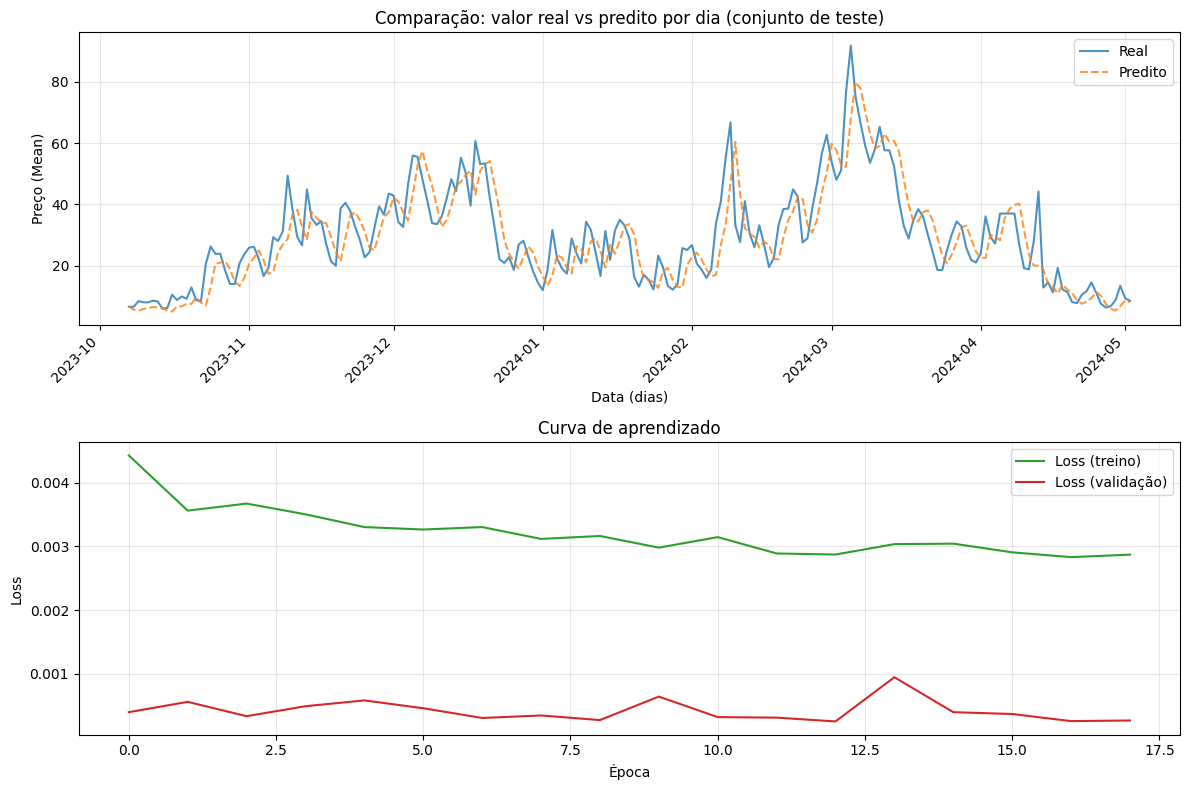

In [13]:
# 6. Gráficos de comparação
# Eixo x: datas/dias do conjunto de teste (um ponto por dia)
time_col = "Date" if "Date" in df.columns else ("signed_at" if "signed_at" in df.columns else "date")
val_end = len(X_train) + len(X_val)
test_start_idx = config.window_size + val_end + config.forecast_horizon - 1
dates_test = df[time_col].iloc[test_start_idx : test_start_idx + len(y_test)]
if not pd.api.types.is_datetime64_any_dtype(dates_test):
    dates_test = pd.to_datetime(dates_test, errors="coerce")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 6.1 Real vs Predito (conjunto de teste) — eixo x = dias/datas
ax1 = axes[0]
ax1.plot(dates_test, y_test_orig, label="Real", color="tab:blue", alpha=0.8)
ax1.plot(dates_test, y_pred_orig, label="Predito", color="tab:orange", alpha=0.8, linestyle="--")
ax1.set_xlabel("Data (dias)")
ax1.set_ylabel(f"Preço ({target_column})")
ax1.set_title("Comparação: valor real vs predito por dia (conjunto de teste)")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 6.2 Curva de loss no treino
ax2 = axes[1]
ax2.plot(history.history["loss"], label="Loss (treino)", color="tab:green")
ax2.plot(history.history["val_loss"], label="Loss (validação)", color="tab:red")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.set_title("Curva de aprendizado")
ax2.legend(loc="upper right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Métricas no teste (escala original)
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
print(f"MAE (teste): {mae:.4f}")
print(f"RMSE (teste): {rmse:.4f}")

MAE (teste): 6.3219
RMSE (teste): 8.3215
